In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath ="/content/drive/MyDrive/Colab Notebooks/PGDBA-Project"

In [ ]:
! pip install python_speech_features

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for python_speech_features: filename=python_speech_features-0.6-py3-none-any.whl size=5870 sha256=b05756d8696bafa9e2424e7554df6288b8a35add68abd92a74d924c0e54dad8b
  Stored in directory: /root/.cache/pip/wheels/5a/9e/68/30bad9462b3926c29e315df16b562216d12bdc215f4d240294
Successfully built python_speech_features


In [ ]:
import os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from python_speech_features import mfcc, logfbank
import librosa
from audio_utils import envelope, plot_signals, plot_fft, plot_fbank, plot_mfccs, calc_fft

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/instruments.csv")

In [ ]:
df.set_index('fname',inplace=True)

In [ ]:
for f in df.index:
  rate,signal=wavfile.read("/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/wavfiles/"+f)
  df.at[f,'length']=signal.shape[0]/rate

In [ ]:
df

,label,length
fname,,
5388d14d.wav,Saxophone,4.14
c685f05f.wav,Saxophone,1.54
36d20ab5.wav,Saxophone,4.90
d6665734.wav,Saxophone,10.50
7352e28f.wav,Saxophone,6.24
...,...,...
3c713bcf.wav,Clarinet,6.14
2fc00271.wav,Clarinet,4.20
b0c06255.wav,Clarinet,4.08


In [ ]:
classes=list(np.unique(df.label))

In [ ]:
class_dist=df.groupby(['label'])['length'].mean()


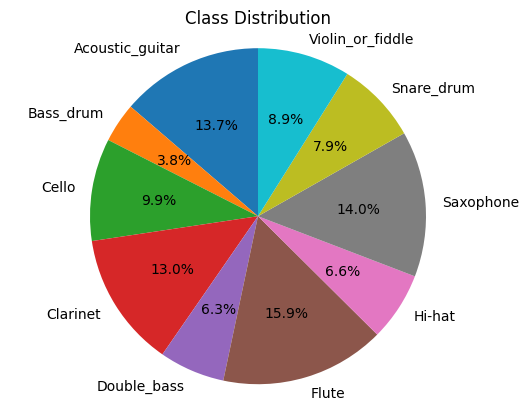

In [ ]:
fig,ax=plt.subplots()
ax.set_title("Class Distribution",y=1.00)
ax.pie(class_dist,labels=class_dist.index,autopct='%1.1f%%',shadow=False,startangle=90)
ax.axis('equal')
plt.show()
df.reset_index(inplace=True)

In [ ]:
def plot_signals(signals):
    fig, axes = plt.subplots(nrows=2, ncols=5, sharex=False,
                             sharey=True, figsize=(20,5))
    fig.suptitle('Time Series', size=16)
    i = 0
    for x in range(2):
        for y in range(5):
            axes[x,y].set_title(list(signals.keys())[i])
            axes[x,y].plot(list(signals.values())[i])
            axes[x,y].get_xaxis().set_visible(False)
            axes[x,y].get_yaxis().set_visible(False)
            i += 1

def plot_fft(fft):
    fig, axes = plt.subplots(nrows=2, ncols=5, sharex=False,
                             sharey=True, figsize=(20,5))
    fig.suptitle('Fourier Transforms', size=16)
    i = 0
    for x in range(2):
        for y in range(5):
            data = list(fft.values())[i]
            Y, freq = data[0], data[1]
            axes[x,y].set_title(list(fft.keys())[i])
            axes[x,y].plot(freq, Y)
            axes[x,y].get_xaxis().set_visible(False)
            axes[x,y].get_yaxis().set_visible(False)
            i += 1

def plot_fbank(fbank):
    fig, axes = plt.subplots(nrows=2, ncols=5, sharex=False,
                             sharey=True, figsize=(20,5))
    fig.suptitle('Filter Bank Coefficients', size=16)
    i = 0
    for x in range(2):
        for y in range(5):
            axes[x,y].set_title(list(fbank.keys())[i])
            axes[x,y].imshow(list(fbank.values())[i],
                    cmap='hot', interpolation='nearest')
            axes[x,y].get_xaxis().set_visible(False)
            axes[x,y].get_yaxis().set_visible(False)
            i += 1

def plot_mfccs(mfccs):
    fig, axes = plt.subplots(nrows=2, ncols=5, sharex=False,
                             sharey=True, figsize=(20,5))
    fig.suptitle('Mel Frequency Cepstrum Coefficients', size=16)
    i = 0
    for x in range(2):
        for y in range(5):
            axes[x,y].set_title(list(mfccs.keys())[i])
            axes[x,y].imshow(list(mfccs.values())[i],
                    cmap='hot', interpolation='nearest')
            axes[x,y].get_xaxis().set_visible(False)
            axes[x,y].get_yaxis().set_visible(False)
            i += 1


In [ ]:
signals={}
fft={}
fbank={}
mfccs={}

In [ ]:
def calc_fft(y,rate):
  n=len(y)
  freq=np.fft.rfftfreq(n,d=1/rate)
  Y=abs(np.fft.rfft(y)/n)
  return(Y,freq)

In [ ]:
for c in classes:
  wav_file=df[df.label==c].iloc[0,0]
  signal,rate=librosa.load("/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/wavfiles/"+wav_file,sr=44100)
  mask=envelope(signal,rate,0.0005)
  signal=signal[mask]
  signals[c]=signal
  fft[c]=calc_fft(signal,rate) 
  bank=logfbank(signal[:rate],rate,nfilt=26,nfft=1103).T
  fbank[c]=bank
  mel=mfcc(signal[:rate],rate,numcep=13,nfilt=26,nfft=1103).T
  mfccs[c]=mel

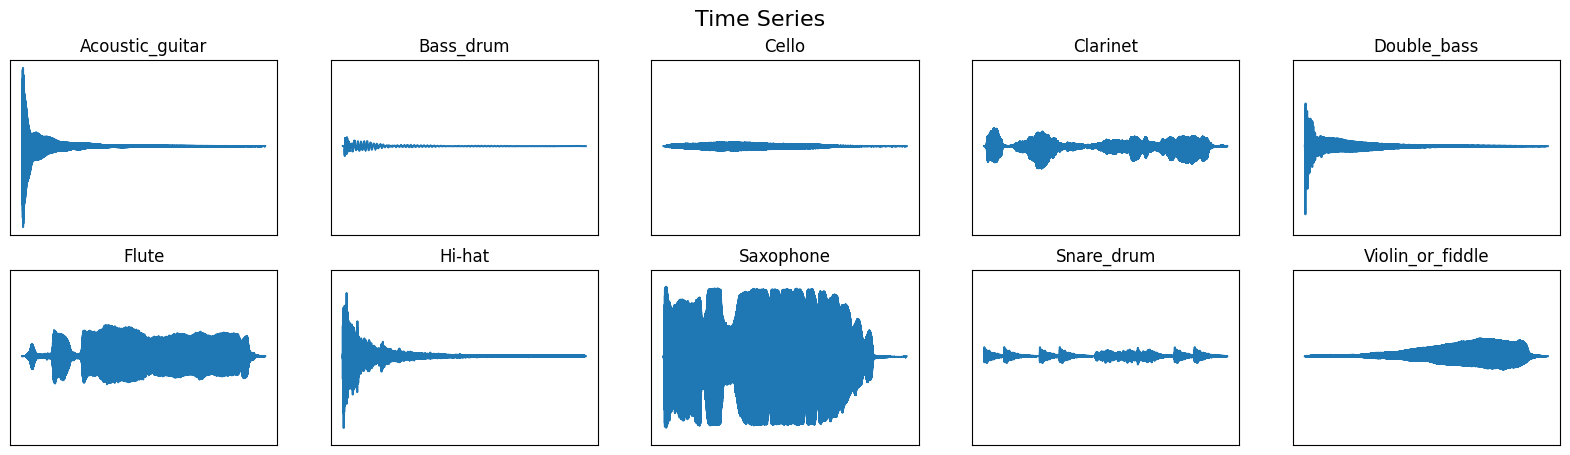

In [ ]:
plot_signals(signals)
plt.show()

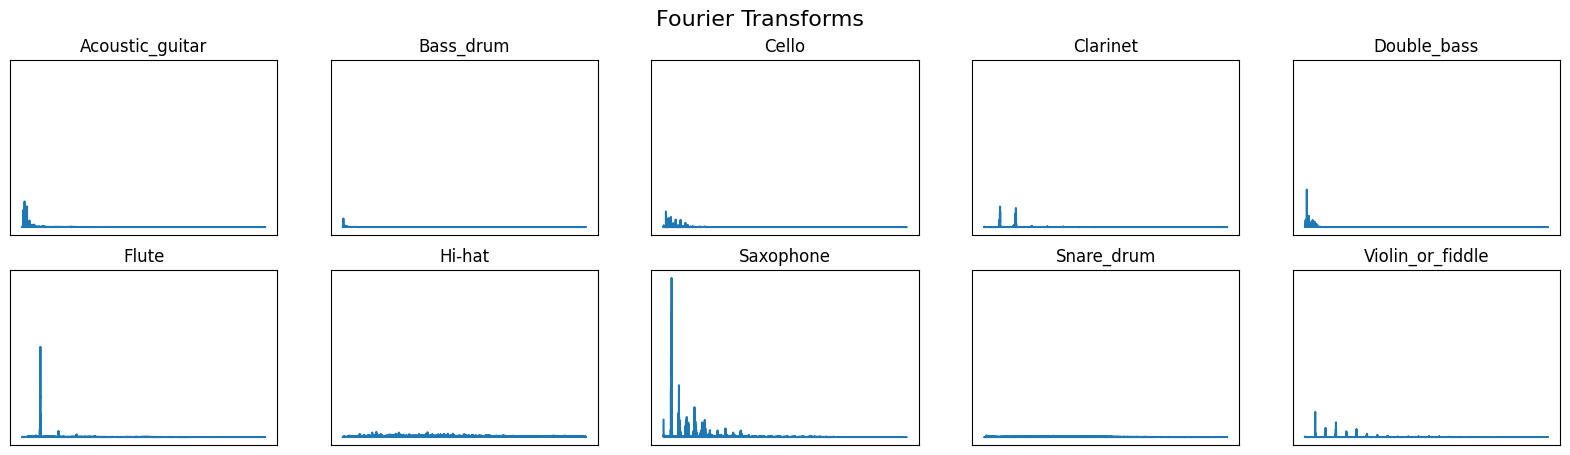

In [ ]:
plot_fft(fft)
plt.show()

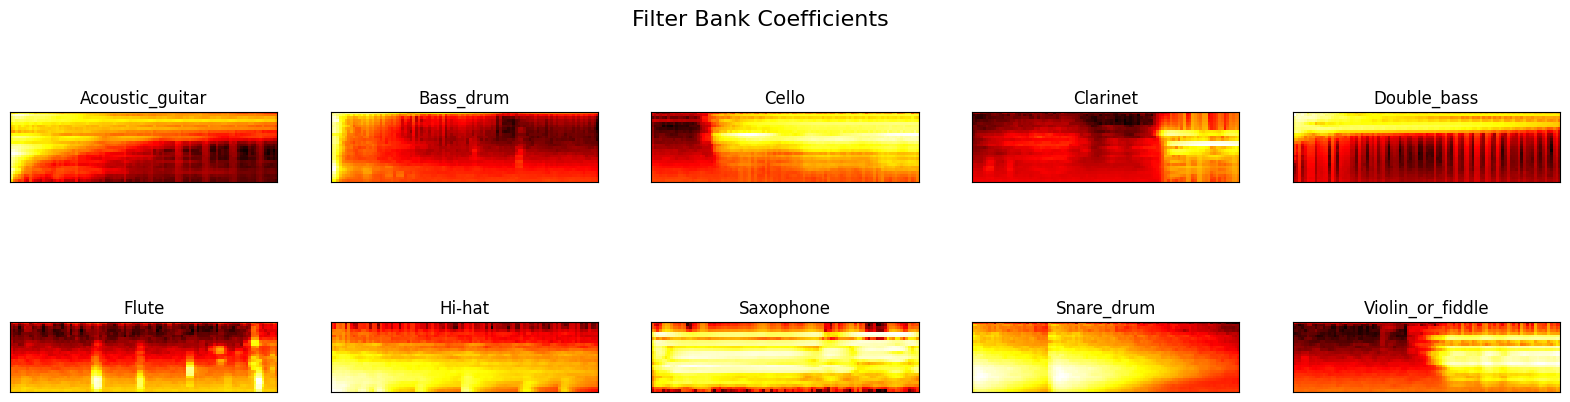

In [ ]:
plot_fbank(fbank)

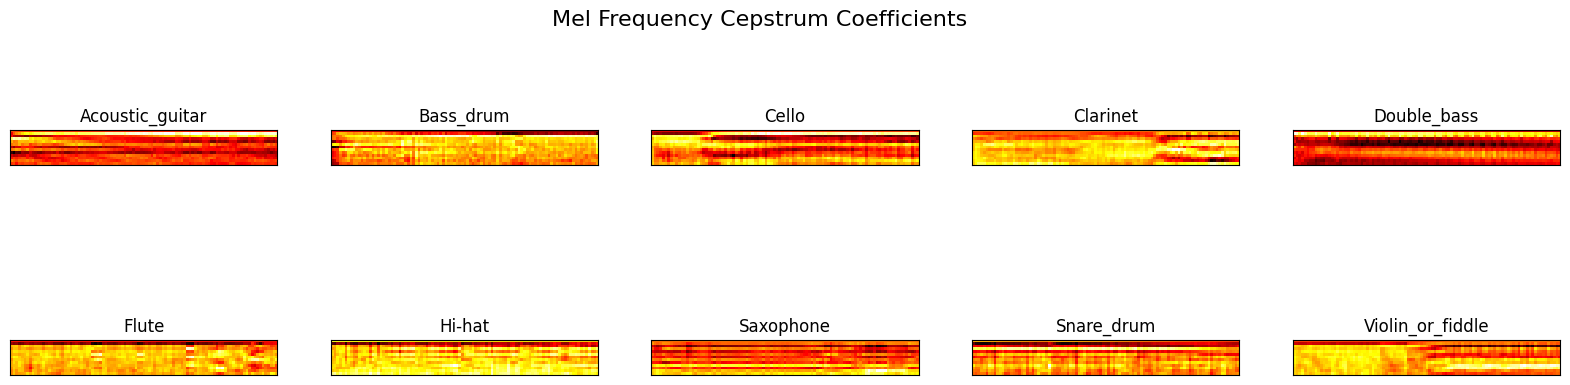

In [ ]:
plot_mfccs(mfccs)
plt.show()

In [ ]:
for f in tqdm(df.fname):
  signal,rate=librosa.load("/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/wavfiles/"+f,sr=16000)
  mask=envelope(signal,rate,0.0005)
  wavfile.write(filename="/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/clean/"+f,rate=rate,data=signal[mask])

100%|██████████| 300/300 [00:13<00:00, 21.86it/s]
